In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression 
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline



## Task1

In [27]:
df = pd.read_csv('Insurance.csv')

In [28]:
print(df.shape)

(1338, 7)


In [29]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [30]:
df_encoded = pd.get_dummies(df, drop_first = True)
X_ins= df_encoded.drop(columns= ['charges'])
y_ins = df_encoded['charges']



In [31]:
X_ins_train, X_ins_test, y_ins_train, y_ins_test = train_test_split(X_ins, y_ins, test_size= 0.2, random_state = 42)

## Task 2

In [32]:
selector = VarianceThreshold(threshold=0)
X_train_vt = selector.fit_transform(X_ins_train)
X_test_vt = selector.transform(X_ins_test)
selected = selector.get_support()
kept = X_ins_train.columns[selected]
X_train_vt = pd.DataFrame(X_train_vt, columns=kept)
X_test_vt = pd.DataFrame(X_test_vt, columns=kept)

print(selected)

[ True  True  True  True  True  True  True  True]


In [33]:
print(X_ins_train.columns[selected])


Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


In [34]:
X_ins_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


## Notes: Features have high variance as seen when going from .01 to 1.

## Task 3

In [35]:
skb = SelectKBest(score_func=f_regression, k = 'all' )
X_train_skb = skb.fit_transform(X_train_vt, y_ins_train)
X_ins_test = skb.transform(X_test_vt)

print(X_train_skb)

[[46.    19.95   2.    ...  1.     0.     0.   ]
 [47.    24.32   0.    ...  0.     0.     0.   ]
 [52.    24.86   0.    ...  0.     1.     0.   ]
 ...
 [58.    25.175  0.    ...  0.     0.     0.   ]
 [37.    47.6    2.    ...  0.     0.     1.   ]
 [55.    29.9    0.    ...  0.     0.     1.   ]]


In [36]:
scores = pd.Series(skb.scores_, index=X_train_vt.columns)
print(scores.sort_values(ascending=False))

smoker_yes          1659.952101
age                   92.070905
bmi                   43.265710
children               5.547503
region_southeast       4.887087
sex_male               3.457075
region_southwest       1.309463
region_northwest       1.219783
dtype: float64


1. Smoker_yes had the highest score.
2. Yes it does match because smokers usually have higher insurance cost.
3. High scores mean they correlate with the charge cost.

In [37]:
#Task 4

lasso = Lasso(alpha=100, random_state=42)
lasso.fit(X_ins_train, y_ins_train)
print(pd.Series(lasso.coef_, index=X_ins.columns).sort_values())

sex_male                0.000000
region_southwest       -0.000000
region_southeast       -0.000000
region_northwest        0.000000
age                   256.128819
bmi                   324.835277
children              362.948153
smoker_yes          23041.824357
dtype: float64


When lasso gives a column a coefficient of zero, it means that the column was dropped.
This is different from SelectKBest because SelectKBest only ranks the categories while lasso drops them.

In [38]:
#Task 5

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_ins_train, y_ins_train)

importances = pd.Series(rf.feature_importances_, index = X_ins.columns).sort_values()
print(importances)



region_southwest    0.003950
region_southeast    0.005314
region_northwest    0.005587
sex_male            0.006379
children            0.019413
age                 0.134232
bmi                 0.216506
smoker_yes          0.608618
dtype: float64


Text(0.5, 0, 'Importance')

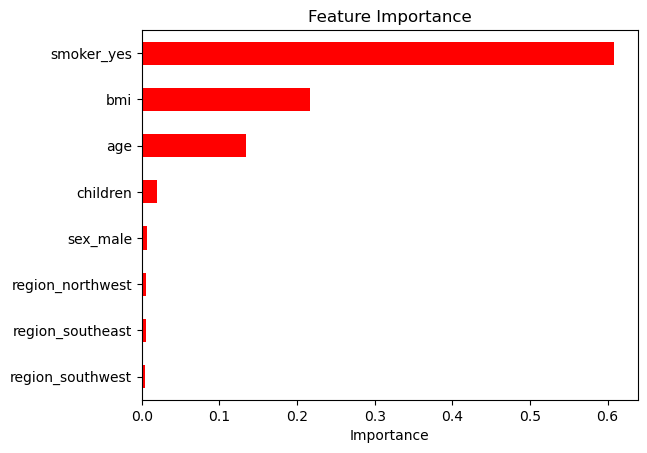

In [39]:
importances.plot(kind="barh", color="Red" )
plt.title("Feature Importance")
plt.xlabel("Importance")


SelectKBest and Lasso's top features is smoker_yes. They agree that smoker_yes is a huge factor to charge cost. They disagree on children, lasso thinks children are more important when it comes to charge cost while SelectKBest doesn't. 

## Task 6


In [40]:
result = permutation_importance(
  rf,
  X_ins_test,
  y_ins_test,
  n_repeats= 10,
  random_state = 42
)

c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\cruss\anaconda3\Lib\site-packages\sklearn\base.py:493: U

In [41]:
perm_imp = pd.Series(
   result.importances_mean,
   index=X_ins.columns

).sort_values(ascending=False)

print("Permutation Importances (test set)")
print(perm_imp)

Permutation Importances (test set)
smoker_yes          1.375150
bmi                 0.263500
age                 0.190867
children            0.026610
region_southeast    0.005043
region_southwest    0.002763
region_northwest    0.001363
sex_male           -0.002445
dtype: float64


In [42]:
## 1. Sex male moved down. A much more trustworthy result is due to not overfitting the training data causing inflated Importance scores.

## Task 7

In [46]:
pipe = Pipeline([
     ('scaler', StandardScaler()),
     ('model', RandomForestRegressor(random_state=42))
])

pipe_params = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10]

}

pipe_search = GridSearchCV(
    estimator=pipe,
    param_grid = pipe_params,
    cv = 5,
    scoring='r2',
    n_jobs = -1

)
pipe_search.fit(X_ins_train, y_ins_train)
print("Best pipeline params:", pipe_search.best_params_)
print("Best pipeline params:", pipe_search.best_score_)


Best pipeline params: {'model__max_depth': 5, 'model__n_estimators': 200}
Best pipeline params: 0.8444609754900883


##### 1. It prevents data leakage.
##### 2. There will be overly optimistic performance estimates, poor generalization and Biased hyperparameter also, you are scaling on the entire dataset.